<a href="https://colab.research.google.com/github/sanjay-MGR/Machine-Learning-basic-/blob/main/simple_and_multiple_Linear_Regression(Revision).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import laiberies /
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset
data = sns.load_dataset('mpg')
data.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320


In [ ]:
df1 = data[['mpg','cylinders','displacement','horsepower','acceleration']]

In [ ]:
df1.head(2)

,mpg,cylinders,displacement,horsepower,acceleration
0,18.0,8,307.0,130.0,12.0
1,15.0,8,350.0,165.0,11.5


In [ ]:
#handel null values
df1.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
acceleration,0


In [ ]:
df1['horsepower'] = df1['horsepower'].fillna(df1['horsepower'].mean())

/tmp/ipykernel_8899/1684296102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['horsepower'] = df1['horsepower'].fillna(df1['horsepower'].mean())


In [ ]:
df1.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
acceleration,0


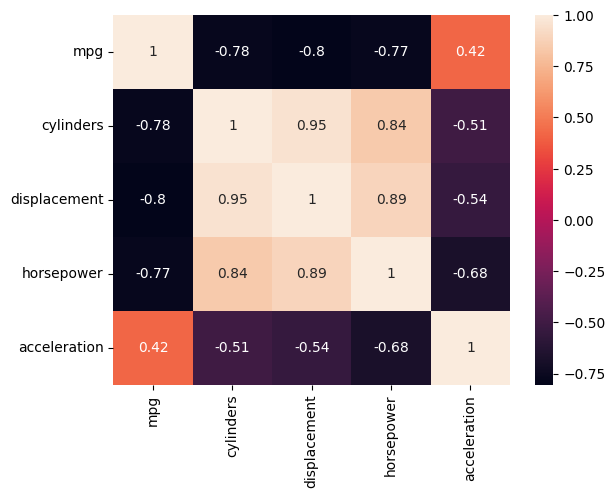

In [ ]:
#find the correlation
sns.heatmap(df1[['mpg','cylinders','displacement','horsepower','acceleration']].corr(),annot = True )
plt.savefig('mpg.png')
plt.show()

In [ ]:
# Simple linear Regression

In [ ]:

df = df1[['horsepower','mpg']]
x = df['horsepower']
y = df['mpg']

In [ ]:
#import model
from sklearn.linear_model import LinearRegression

In [ ]:
#build model
slm = LinearRegression()
slm

LinearRegression()

In [ ]:
#fit model
slm.fit(x.values.reshape(-1,1),y)

LinearRegression()

In [ ]:
#find coefficent
model_coef = slm.coef_
model_coef

array([-0.15784473])

In [ ]:
#find the model interception
model_intercept = slm.intercept_
model_intercept

np.float64(40.00451551814514)

In [ ]:
#predict the value
y_pred = slm.predict(x.values.reshape(-1,1))#Machine learning models expect data in 2D format.(reshape(-1,1))
y_pred

array([19.48470018, 13.96013451, 16.32780552, 16.32780552, 17.90625285,
        8.75125831,  5.27867418,  6.06789785,  4.48945051, 10.01401618,
       13.17091085, 14.74935818, 16.32780552,  4.48945051, 25.00926585,
       25.00926585, 24.69357638, 26.58771318, 26.11417898, 32.74365778,
       26.27202372, 25.79848952, 25.00926585, 22.16806065, 25.79848952,
        6.06789785,  8.43556885,  6.85712151,  9.54048198, 26.11417898,
       25.79848952, 25.00926585, 23.51457286, 24.22004218, 23.43081852,
       24.22004218, 26.11417898, 24.22004218, 13.96013451, 12.38168718,
       15.85427132, 16.32780552, 11.59246351, 13.17091085, 12.38168718,
       22.64159485, 28.63969472, 24.22004218, 26.11417898, 26.42986845,
       25.79848952, 28.95538418, 28.00831578, 29.74460785, 29.11322892,
       30.53383152, 28.95538418, 25.00926585, 27.37693685, 31.48089992,
       25.79848952, 26.42986845, 13.96013451, 12.38168718, 16.32780552,
       15.85427132, 16.32780552,  7.17281098, 15.53858185, 14.74

In [ ]:
#convert Output into DataFrame
y_pred_df = pd.DataFrame(y_pred,columns = ['Y_pred'])
y_pred_df.head(2)

,Y_pred
0,19.484700
1,13.960135


In [ ]:
y_pred_df.shape

(398, 1)

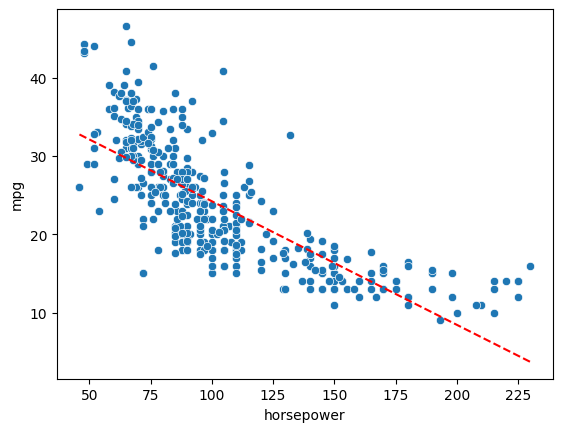

In [ ]:
#visualization
x_max = df['horsepower'].max()
x_min = df['horsepower'].min()
x_vals = np.linspace(x_min, x_max, 100) #creates 100 evenly spaced values between minimum and maximum horsepower.
y_vals = slm.predict(x_vals.reshape(-1,1))#Machine learning models expect data in 2D format.(reshape(-1,1))
sns.scatterplot(x = 'horsepower',y='mpg',data =df )
plt.plot(x_vals,y_vals,color = 'red',linestyle='--')
plt.show()

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [ ]:
r2_s = r2_score(y,y_pred)
r2_s

0.5951152532609462

In [ ]:
mae = mean_absolute_error(y,y_pred)
mae

3.857994255764853

In [ ]:
mse = mean_squared_error(y,y_pred)
mse

24.672105225958788

In [ ]:
# For Multiple Linear Regression

In [ ]:
df1

,mpg,cylinders,displacement,horsepower,acceleration
0,18.0,8,307.0,130.0,12.0
1,15.0,8,350.0,165.0,11.5
2,18.0,8,318.0,150.0,11.0
3,16.0,8,304.0,150.0,12.0
4,17.0,8,302.0,140.0,10.5
...,...,...,...,...,...
393,27.0,4,140.0,86.0,15.6
394,44.0,4,97.0,52.0,24.6
395,32.0,4,135.0,84.0,11.6
396,28.0,4,120.0,79.0,18.6


In [ ]:
data_new = df1.copy() # copy df1 data to the data_new

In [ ]:
data_new.isna().sum() # there is no nulll value

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
acceleration,0


In [ ]:
#split data into x and y
x = data_new.drop('mpg',axis = 1)
x.head(5)

,cylinders,displacement,horsepower,acceleration
0,8,307.0,130.0,12.0
1,8,350.0,165.0,11.5
2,8,318.0,150.0,11.0
3,8,304.0,150.0,12.0
4,8,302.0,140.0,10.5


In [ ]:
y = data_new['mpg']
y.head(5)

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [ ]:
#Build the regression model
Mlinearmodel = LinearRegression()
Mlinearmodel

LinearRegression()

In [ ]:
#fit model
Mlinearmodel.fit(x,y)

LinearRegression()

In [ ]:
#find interception
Intercept = Mlinearmodel.intercept_
Intercept

In [ ]:
#find the coefficent
coeffient = Mlinearmodel.coef_
coeffient

array([-0.64856688, -0.02876185, -0.082378  , -0.38304821])

In [ ]:
# predicti the oucome
y_predt = Mlinearmodel.predict(x)
y_predt

array([17.86081131, 13.93234589, 16.27991922, 16.29953696, 17.75541294,
        9.51625795,  7.36794393,  8.37402396,  6.54424389, 11.8715665 ,
       13.14588707, 15.97252313, 14.49601957,  6.54424389, 27.76896357,
       23.83554817, 23.64203033, 24.41028032, 28.99732329, 30.15890983,
       27.55665256, 28.54494877, 27.07019972, 27.01368535, 24.4102004 ,
        8.56820706, 10.945207  , 10.37961898, 10.26746979, 28.99732329,
       27.2127594 , 28.15201178, 25.88812935, 23.40337571, 22.23519818,
       21.92804183, 22.91657777, 22.44575519, 13.74082178, 11.67047327,
       14.12602356, 15.5138228 , 11.7475348 , 11.89083914, 11.47894916,
       21.64026347, 27.35489458, 22.11956593, 23.29962598, 28.63455706,
       28.4776162 , 29.08259952, 30.24471592, 29.91610842, 29.9408828 ,
       29.58019022, 28.35440907, 27.57743946, 28.6843458 , 28.35074124,
       25.68056656, 27.67693653, 13.74082178, 11.47894916, 15.3222987 ,
       14.31754766, 16.49106107,  8.30942978, 13.99002942, 13.57

In [ ]:
#check the accuracy
r2_scoress = r2_score(y,y_predt)
r2_scoress

0.6718030857932036

In [ ]:
#mean squre error
mses = mean_squared_error(y,y_predt)
mses

19.999046314687977